In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(x1, x2, x3):
    return x1**2 + 8*x1 + 5*x2**2 + 7*x3**2 + 119.0*x3 + 531.75

def quadratic_interpolation(f, a, b, c, tol=1e-6):
    for _ in range(100):
        fa, fb, fc = f(a), f(b), f(c)
        
        denom = (b - a)*(b - c)*(a - c)
        if abs(denom) < 1e-12:
            break
            
        A = ((fb - fc)*(a - c) - (fa - fc)*(b - c)) / denom
        B = ((fa - fc)*(b**2 - c**2) - (fb - fc)*(a**2 - c**2)) / denom
        
        if A <= 0:
            return b
        
        x_min = -B / (2*A)
        
        if x_min < b:
            if x_min > a:
                c, b = b, x_min
            else:
                c, b, a = b, a, x_min
        else:
            if x_min < c:
                a, b = b, x_min
            else:
                a, b, c = b, c, x_min
        
        if abs(c - a) < tol:
            break
    
    return b

def powell_method(x_start, epsilon=0.001, max_iter=1000):
    n = 3
    x = np.array(x_start, dtype=float)
    directions = np.eye(n)
    
    x_way = [x.copy()]
    f_way = [f(*x)]
    iter_count = 0
    
    while iter_count < max_iter:
        iter_count += 1
        x_old = x.copy()
        
        for i in range(n):
            def f_line(alpha):
                return f(*(x + alpha * directions[i]))
            
            a, b, c = -1, 0, 1
            alpha_min = quadratic_interpolation(f_line, a, b, c, epsilon)
            
            x += alpha_min * directions[i]
            x_way.append(x.copy())
            f_way.append(f(*x))
        
        new_direction = x - x_old
        if np.linalg.norm(new_direction) > epsilon:
            new_direction = new_direction / np.linalg.norm(new_direction)
            directions = np.vstack([directions[1:], new_direction])
        
        if np.linalg.norm(x - x_old) < epsilon:
            break
    
    print('Количество итераций:', iter_count)
    return f(*x), x[0], x[1], x[2], x_way

x_start = [8, -2, 6]
epsilon = 0.01

f_min, x1_end, x2_end, x3_end, x_way = powell_method(x_start, epsilon=epsilon)

print('Минимум функции:', f_min)
print('Координаты минимума:', (x1_end, x2_end, x3_end))


Количество итераций: 2
Минимум функции: 9.999999999999886
Координаты минимума: (-4.0000000000000036, 6.577431916249561e-16, -8.500000000000005)


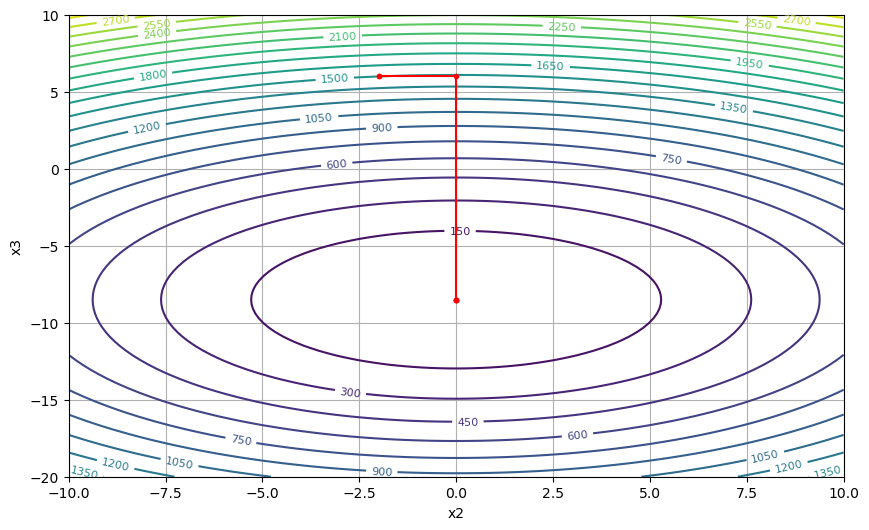

In [7]:
x1_vals = np.linspace(-10, 10, 100)
x2_vals = np.linspace(-20, 10, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(x1_end, X1, X2)

path_x2 = [point[1] for point in x_way]
path_x3 = [point[2] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x2, path_x3, 'r.-')

plt.xlabel('x2')
plt.ylabel('x3')

plt.grid()
plt.show()

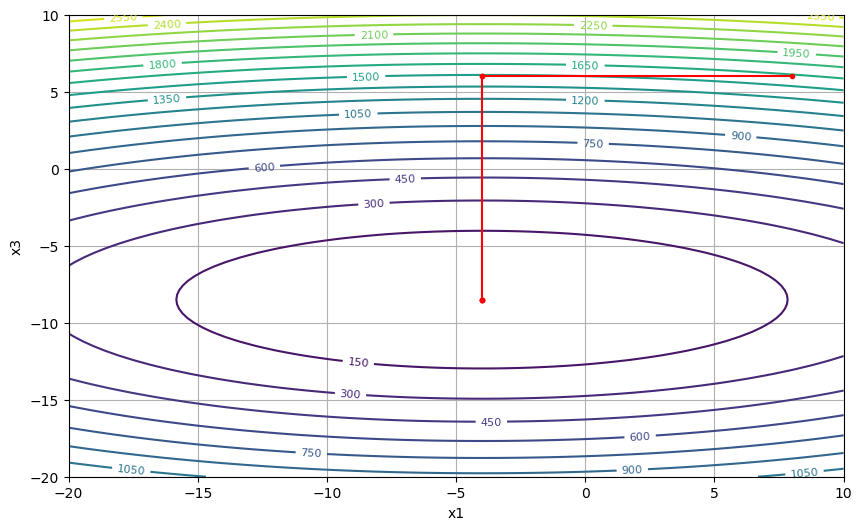

In [8]:
x1_vals = np.linspace(-20, 10, 100)
x2_vals = np.linspace(-20, 10, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, x2_end, X2)

path_x1 = [point[0] for point in x_way]
path_x3 = [point[2] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x1, path_x3, 'r.-')

plt.xlabel('x1')
plt.ylabel('x3')

plt.grid()
plt.show()

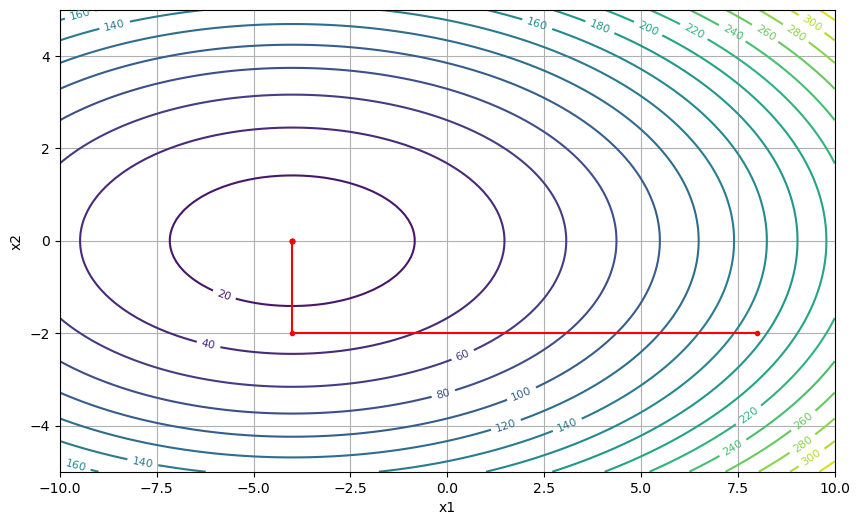

In [9]:
x1_vals = np.linspace(-10, 10, 100)
x2_vals = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2, x3_end)

path_x1 = [point[0] for point in x_way]
path_x2 = [point[1] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x1, path_x2, 'r.-')

plt.xlabel('x1')
plt.ylabel('x2')

plt.grid()
plt.show()